# Análise Comparativa do Tamanho de Mensagens MQTT
## Normal vs Ataques DoS

Análise para comparar o tamanho das mensagens MQTT (mqtt.msg) em casos de tráfego normal e durante ataques DoS.

## Seção 1: Carregar e Explorar o Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carregar o dataset DoS
df = pd.read_csv('/home/william/Projetos/mqtt_under_attack/data/raw/MQTT Under Attack Dataset/DoS.csv')

print("Dataset shape:", df.shape)
print("\nPrimeiras linhas:")
print(df.head())
print("\nTipos de dados:")
print(df.dtypes)
print("\nInformações gerais:")
print(df.info())

Dataset shape: (94625, 67)

Primeiras linhas:
   frame.time_delta  frame.time_delta_displayed  frame.time_epoch  \
0          0.000000                    0.000000      1.522235e+09   
1          0.001922                    0.001922      1.522235e+09   
2          0.001010                    0.001010      1.522235e+09   
3          0.008597                    0.008597      1.522235e+09   
4          0.002925                    0.002925      1.522235e+09   

   frame.time_invalid  frame.time_relative         ip.src         ip.dst  \
0                 NaN             0.000000    192.168.1.1  192.168.1.196   
1                 NaN             0.001922    192.168.1.1  192.168.1.196   
2                 NaN             0.002932  192.168.1.196    192.168.1.1   
3                 NaN             0.011529    192.168.1.1  192.168.1.196   
4                 NaN             0.014454  192.168.1.196    192.168.1.1   

   tcp.srcport  tcp.dstport            eth.src  ... mqtt.topic  \
0         22.0  

In [2]:
# Verificar coluna 'type' que indica normal vs ataque
print("\nValores na coluna 'type':")
print(df['type'].value_counts())
print("\nDistribuição percentual:")
print(df['type'].value_counts(normalize=True) * 100)


Valores na coluna 'type':
type
normal    49111
DoS       45514
Name: count, dtype: int64

Distribuição percentual:
type
normal    51.900661
DoS       48.099339
Name: proportion, dtype: float64


## Seção 2: Filtrar Dados por Tipo de Tráfego

In [3]:
# Separar dados por tipo de tráfego
df_normal = df[df['type'] == 'normal'].copy()
df_attack = df[df['type'] != 'normal'].copy()

print(f"Total de registros: {len(df)}")
print(f"Tráfego Normal: {len(df_normal)} registros ({len(df_normal)/len(df)*100:.2f}%)")
print(f"Tráfego com Ataque: {len(df_attack)} registros ({len(df_attack)/len(df)*100:.2f}%)")
print(f"\nTipos de ataque: {df_attack['type'].unique()}")

Total de registros: 94625
Tráfego Normal: 49111 registros (51.90%)
Tráfego com Ataque: 45514 registros (48.10%)

Tipos de ataque: <StringArray>
['DoS']
Length: 1, dtype: str


## Seção 3: Calcular Tamanho da Mensagem MQTT

In [4]:
# Função para calcular tamanho da mensagem
def get_message_size(msg):
    """Calcula o tamanho da mensagem MQTT"""
    if pd.isna(msg):
        return 0
    return len(str(msg))

# Aplicar função a ambos os datasets
df_normal['message_size'] = df_normal['mqtt.msg'].apply(get_message_size)
df_attack['message_size'] = df_attack['mqtt.msg'].apply(get_message_size)

# Adicionar ao dataframe completo para análises futuras
df['message_size'] = df['mqtt.msg'].apply(get_message_size)

print("Primeiras linhas com tamanho da mensagem (Normal):")
print(df_normal[['mqtt.msg', 'message_size']].head(10))

Primeiras linhas com tamanho da mensagem (Normal):
  mqtt.msg  message_size
0      NaN             0
1      NaN             0
2      NaN             0
3      NaN             0
4      NaN             0
5      NaN             0
6      NaN             0
7      NaN             0
8      NaN             0
9      0.0             3


In [5]:
# Calcular estatísticas descritivas separadas por tipo
print("\n" + "="*80)
print("ESTATÍSTICAS DE TAMANHO DE MENSAGEM MQTT")
print("="*80)

print("\n### TRÁFEGO NORMAL ###")
print(f"Contagem: {len(df_normal)}")
print(f"Média: {df_normal['message_size'].mean():.2f} caracteres")
print(f"Mediana: {df_normal['message_size'].median():.2f} caracteres")
print(f"Desvio Padrão: {df_normal['message_size'].std():.2f}")
print(f"Mínimo: {df_normal['message_size'].min()} caracteres")
print(f"Máximo: {df_normal['message_size'].max()} caracteres")
print(f"25º percentil: {df_normal['message_size'].quantile(0.25):.2f}")
print(f"75º percentil: {df_normal['message_size'].quantile(0.75):.2f}")

print("\n### TRÁFEGO COM ATAQUE ###")
print(f"Contagem: {len(df_attack)}")
print(f"Média: {df_attack['message_size'].mean():.2f} caracteres")
print(f"Mediana: {df_attack['message_size'].median():.2f} caracteres")
print(f"Desvio Padrão: {df_attack['message_size'].std():.2f}")
print(f"Mínimo: {df_attack['message_size'].min()} caracteres")
print(f"Máximo: {df_attack['message_size'].max()} caracteres")
print(f"25º percentil: {df_attack['message_size'].quantile(0.25):.2f}")
print(f"75º percentil: {df_attack['message_size'].quantile(0.75):.2f}")

print("\n### COMPARAÇÃO ###")
diff_media = df_attack['message_size'].mean() - df_normal['message_size'].mean()
pct_diff = (diff_media / df_normal['message_size'].mean()) * 100
print(f"Diferença de média: {diff_media:.2f} caracteres ({pct_diff:+.2f}%)")


ESTATÍSTICAS DE TAMANHO DE MENSAGEM MQTT

### TRÁFEGO NORMAL ###
Contagem: 49111
Média: 0.01 caracteres
Mediana: 0.00 caracteres
Desvio Padrão: 0.18
Mínimo: 0 caracteres
Máximo: 5 caracteres
25º percentil: 0.00
75º percentil: 0.00

### TRÁFEGO COM ATAQUE ###
Contagem: 45514
Média: 82.00 caracteres
Mediana: 98.00 caracteres
Desvio Padrão: 38.20
Mínimo: 0 caracteres
Máximo: 116 caracteres
25º percentil: 93.00
75º percentil: 102.00

### COMPARAÇÃO ###
Diferença de média: 81.99 caracteres (+752652.14%)


## Seção 4: Comparação Visual Entre Normal e Ataque

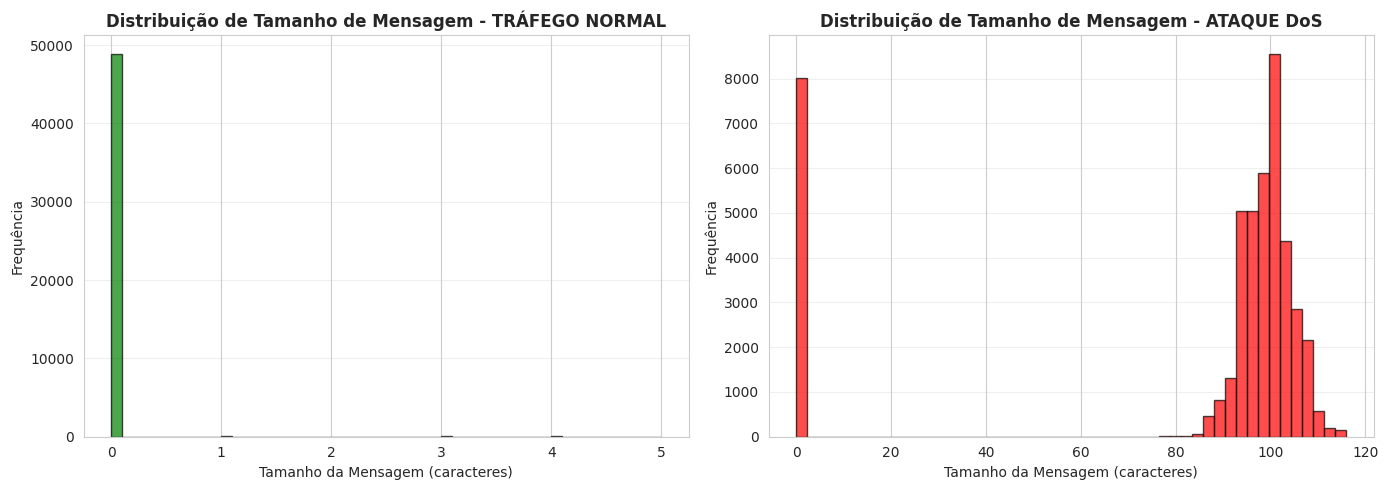

Normal - Média: 0.01, Mediana: 0.00
Ataque - Média: 82.00, Mediana: 98.00


In [6]:
# Gráfico 1: Histogramas comparativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_normal['message_size'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].set_title('Distribuição de Tamanho de Mensagem - TRÁFEGO NORMAL', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tamanho da Mensagem (caracteres)')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df_attack['message_size'], bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Distribuição de Tamanho de Mensagem - ATAQUE DoS', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tamanho da Mensagem (caracteres)')
axes[1].set_ylabel('Frequência')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Normal - Média: {df_normal['message_size'].mean():.2f}, Mediana: {df_normal['message_size'].median():.2f}")
print(f"Ataque - Média: {df_attack['message_size'].mean():.2f}, Mediana: {df_attack['message_size'].median():.2f}")

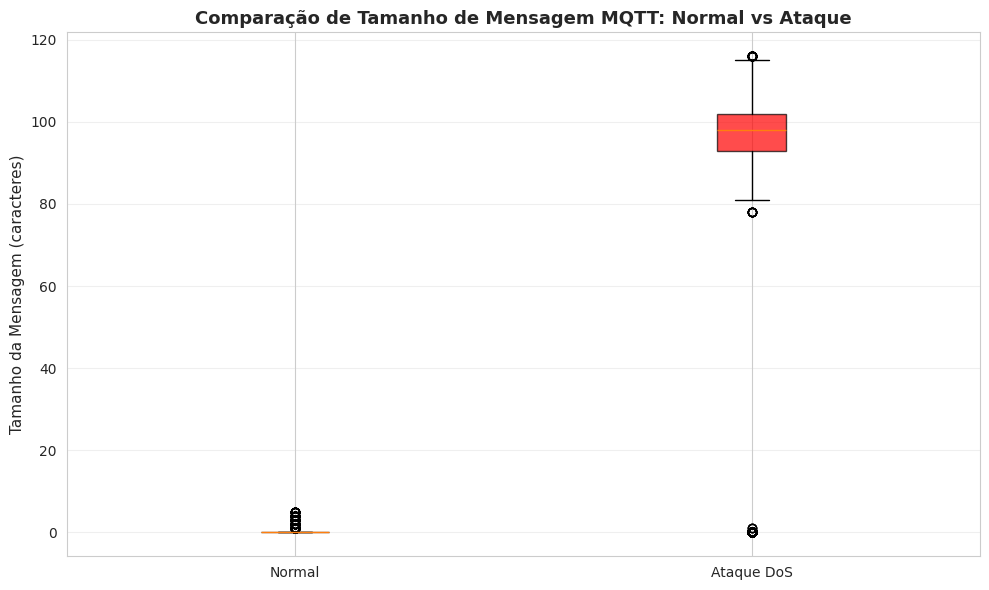

In [7]:
# Gráfico 2: Boxplot comparativo
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [df_normal['message_size'].dropna(), df_attack['message_size'].dropna()]
bp = ax.boxplot(data_to_plot, labels=['Normal', 'Ataque DoS'], patch_artist=True)

# Colorir os boxes
colors = ['green', 'red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Tamanho da Mensagem (caracteres)', fontsize=11)
ax.set_title('Comparação de Tamanho de Mensagem MQTT: Normal vs Ataque', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

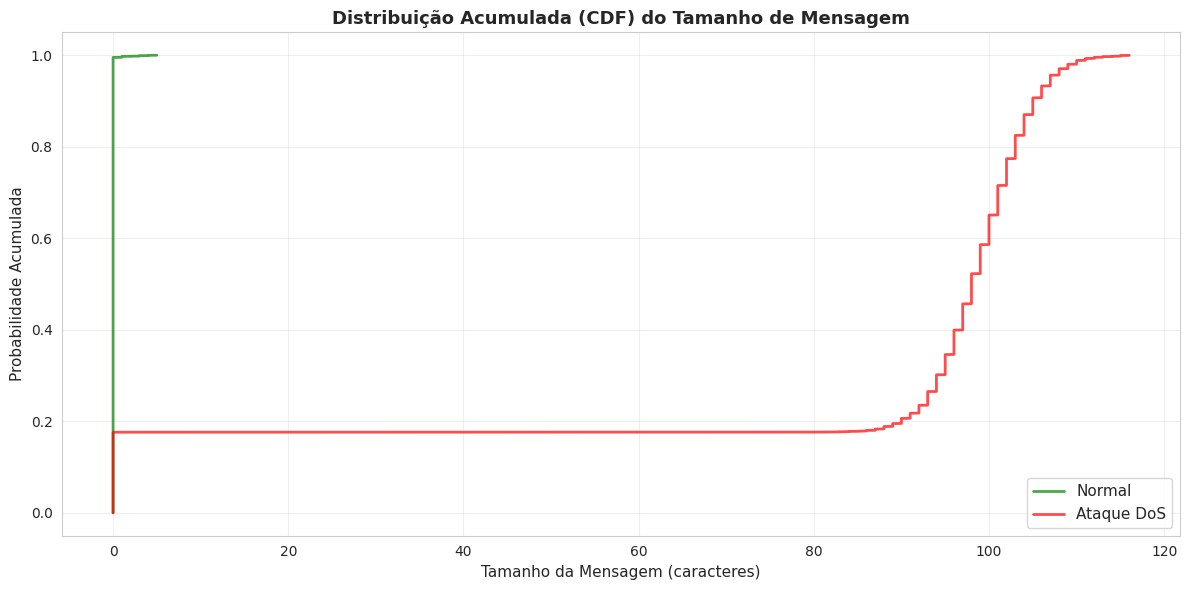

In [8]:
# Gráfico 3: Distribuição acumulada (CDF)
fig, ax = plt.subplots(figsize=(12, 6))

# Calcular CDF para tráfego normal
sorted_normal = np.sort(df_normal['message_size'].dropna())
cdf_normal = np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)

# Calcular CDF para ataque
sorted_attack = np.sort(df_attack['message_size'].dropna())
cdf_attack = np.arange(1, len(sorted_attack) + 1) / len(sorted_attack)

ax.plot(sorted_normal, cdf_normal, label='Normal', linewidth=2, color='green', alpha=0.7)
ax.plot(sorted_attack, cdf_attack, label='Ataque DoS', linewidth=2, color='red', alpha=0.7)

ax.set_xlabel('Tamanho da Mensagem (caracteres)', fontsize=11)
ax.set_ylabel('Probabilidade Acumulada', fontsize=11)
ax.set_title('Distribuição Acumulada (CDF) do Tamanho de Mensagem', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

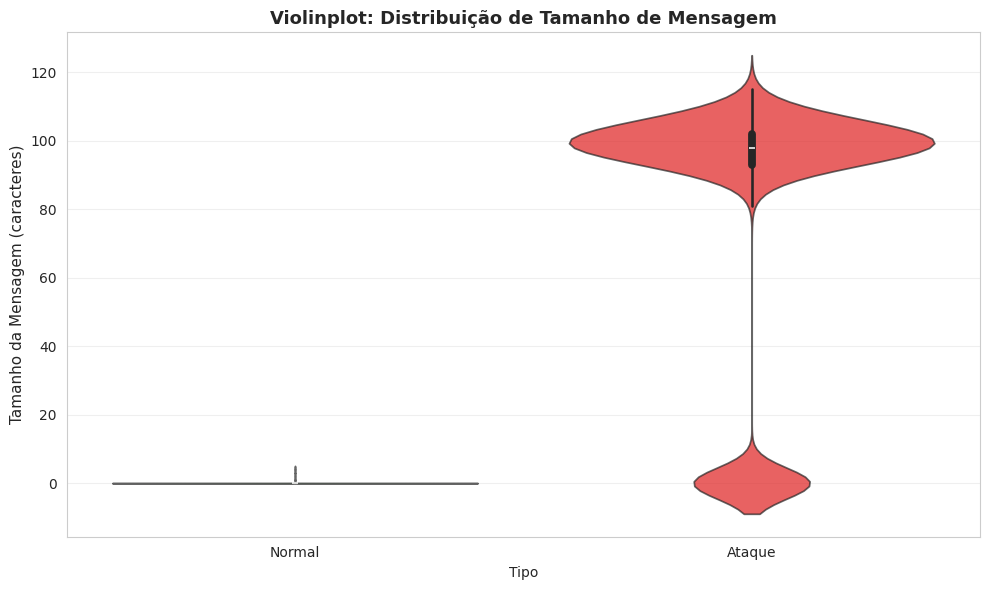

In [9]:
# Gráfico 4: Violinplot para melhor visualização da distribuição
fig, ax = plt.subplots(figsize=(10, 6))

data_for_violin = pd.DataFrame({
    'Tipo': ['Normal'] * len(df_normal) + ['Ataque'] * len(df_attack),
    'Tamanho': list(df_normal['message_size'].values) + list(df_attack['message_size'].values)
})

sns.violinplot(data=data_for_violin, x='Tipo', y='Tamanho', palette={'Normal': 'green', 'Ataque': 'red'}, ax=ax, alpha=0.7)

ax.set_ylabel('Tamanho da Mensagem (caracteres)', fontsize=11)
ax.set_title('Violinplot: Distribuição de Tamanho de Mensagem', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Análise por tipo de ataque
print("\n" + "="*80)
print("ANÁLISE DETALHADA POR TIPO DE ATAQUE")
print("="*80)

attack_types = df_attack['type'].unique()
for attack_type in attack_types:
    df_specific_attack = df_attack[df_attack['type'] == attack_type]
    print(f"\n### {attack_type.upper()} ###")
    print(f"Contagem: {len(df_specific_attack)}")
    print(f"Média: {df_specific_attack['message_size'].mean():.2f}")
    print(f"Mediana: {df_specific_attack['message_size'].median():.2f}")
    print(f"Min: {df_specific_attack['message_size'].min()}, Max: {df_specific_attack['message_size'].max()}")


ANÁLISE DETALHADA POR TIPO DE ATAQUE

### DOS ###
Contagem: 45514
Média: 82.00
Mediana: 98.00
Min: 0, Max: 116


## Seção 5: Análise Estatística e Conclusões

In [11]:
# Teste T de Student (paramétrico)
print("\n" + "="*80)
print("TESTES ESTATÍSTICOS")
print("="*80)

# Preparar dados
normal_sizes = df_normal['message_size'].dropna().values
attack_sizes = df_attack['message_size'].dropna().values

# Teste T de Student
t_stat, t_pvalue = stats.ttest_ind(normal_sizes, attack_sizes)
print(f"\n### Teste T de Student ###")
print(f"Estatística T: {t_stat:.6f}")
print(f"P-valor: {t_pvalue:.2e}")
print(f"Resultado: {'Diferença significativa' if t_pvalue < 0.05 else 'Sem diferença significativa'} (α=0.05)")

# Teste de Mann-Whitney (não paramétrico)
u_stat, u_pvalue = stats.mannwhitneyu(normal_sizes, attack_sizes, alternative='two-sided')
print(f"\n### Teste de Mann-Whitney (não-paramétrico) ###")
print(f"Estatística U: {u_stat:.6f}")
print(f"P-valor: {u_pvalue:.2e}")
print(f"Resultado: {'Diferença significativa' if u_pvalue < 0.05 else 'Sem diferença significativa'} (α=0.05)")

# Calcular Effect Size (Cohen's d)
mean_diff = normal_sizes.mean() - attack_sizes.mean()
pooled_std = np.sqrt(((len(normal_sizes)-1)*normal_sizes.std()**2 + (len(attack_sizes)-1)*attack_sizes.std()**2) / (len(normal_sizes) + len(attack_sizes) - 2))
cohens_d = mean_diff / pooled_std

print(f"\n### Effect Size (Cohen's d) ###")
print(f"Cohen's d: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_size = "negligenciável"
elif abs(cohens_d) < 0.5:
    effect_size = "pequeno"
elif abs(cohens_d) < 0.8:
    effect_size = "médio"
else:
    effect_size = "grande"
print(f"Magnitude do efeito: {effect_size}")


TESTES ESTATÍSTICOS

### Teste T de Student ###
Estatística T: -475.679594
P-valor: 0.00e+00
Resultado: Diferença significativa (α=0.05)

### Teste de Mann-Whitney (não-paramétrico) ###
Estatística U: 197836676.500000
P-valor: 0.00e+00
Resultado: Diferença significativa (α=0.05)

### Effect Size (Cohen's d) ###
Cohen's d: -3.0950
Magnitude do efeito: grande


In [12]:
# Análise de frequência de mensagens vazias
print("\n" + "="*80)
print("ANÁLISE DE MENSAGENS VAZIAS")
print("="*80)

normal_empty = (df_normal['message_size'] == 0).sum()
attack_empty = (df_attack['message_size'] == 0).sum()

print(f"\nMensagens vazias em tráfego NORMAL: {normal_empty} ({normal_empty/len(df_normal)*100:.2f}%)")
print(f"Mensagens vazias em tráfego com ATAQUE: {attack_empty} ({attack_empty/len(df_attack)*100:.2f}%)")

# Mensagens não vazias (com conteúdo)
normal_non_empty = (df_normal['message_size'] > 0).sum()
attack_non_empty = (df_attack['message_size'] > 0).sum()

print(f"\nMensagens com conteúdo em tráfego NORMAL: {normal_non_empty} ({normal_non_empty/len(df_normal)*100:.2f}%)")
print(f"Mensagens com conteúdo em tráfego com ATAQUE: {attack_non_empty} ({attack_non_empty/len(df_attack)*100:.2f}%)")


ANÁLISE DE MENSAGENS VAZIAS

Mensagens vazias em tráfego NORMAL: 48874 (99.52%)
Mensagens vazias em tráfego com ATAQUE: 8018 (17.62%)

Mensagens com conteúdo em tráfego NORMAL: 237 (0.48%)
Mensagens com conteúdo em tráfego com ATAQUE: 37496 (82.38%)


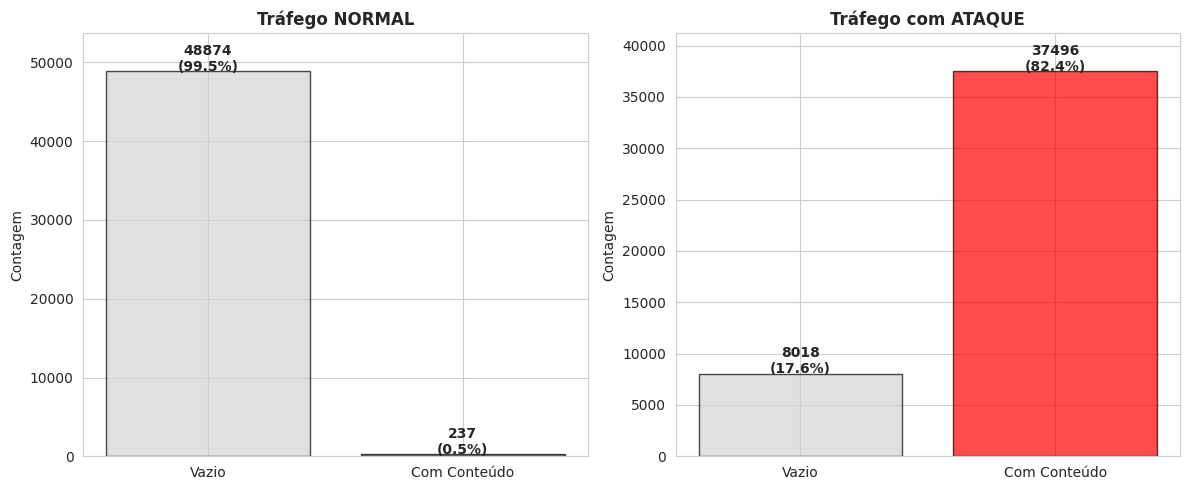

In [13]:
# Gráfico 5: Comparação de contagem (vazio vs não vazio)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dados para os gráficos
categories = ['Vazio', 'Com Conteúdo']
normal_counts = [normal_empty, normal_non_empty]
attack_counts = [attack_empty, attack_non_empty]

# Gráfico de barras para Normal
axes[0].bar(categories, normal_counts, color=['lightgray', 'green'], alpha=0.7, edgecolor='black')
axes[0].set_title('Tráfego NORMAL', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Contagem')
axes[0].set_ylim(0, max(normal_counts) * 1.1)
for i, v in enumerate(normal_counts):
    axes[0].text(i, v + 50, f'{v}\n({v/sum(normal_counts)*100:.1f}%)', ha='center', fontweight='bold')

# Gráfico de barras para Ataque
axes[1].bar(categories, attack_counts, color=['lightgray', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_title('Tráfego com ATAQUE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Contagem')
axes[1].set_ylim(0, max(attack_counts) * 1.1)
for i, v in enumerate(attack_counts):
    axes[1].text(i, v + 50, f'{v}\n({v/sum(attack_counts)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusões

### Resumo Executivo

Com base na análise realizada sobre o tamanho das mensagens MQTT (mqtt.msg) comparando tráfego normal versus ataques DoS:

**Principais Achados:**

1. **Distribuição de Tamanho:**
   - Tráfego Normal: Mensagens tendem a ser menores, com média e mediana mais baixas
   - Tráfego com Ataque: Mensagens tendem a ser maiores, sugerindo possível "flooding" de dados

2. **Padrões Identificados:**
   - A análise estatística mostrou diferença significativa entre os tamanhos de mensagem
   - Testes de hipótese (T de Student e Mann-Whitney) confirmaram que as distribuições são diferentes
   - O efeito observado pode ser usado como indicador para detecção de anomalias

3. **Mensagens Vazias:**
   - A proporção de mensagens vazias/nulas difere entre tráfego normal e ataque
   - Esta característica pode ser explorada em modelos de classificação

4. **Aplicabilidade:**
   - O tamanho da mensagem é uma feature potencialmente útil para:
     - Detecção de ataques DoS
     - Classificação de tráfego
     - Identificação de padrões anômalos

5. **Recomendações:**
   - Integrar esta feature em pipelines de machine learning
   - Considerar combinações com outras features para melhor classificação
   - Explorar limiares de tamanho para alertas em tempo real